In [25]:
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(seed=SEED)

In [26]:
df_path = "../data/data.csv"

df = pd.read_csv(
    filepath_or_buffer=df_path,
    engine='c',
    low_memory=True,
    dtype={'value': 'Int32'},  
    parse_dates=['timestamp'],
    on_bad_lines='skip'
)

df = df.sort_values(
    by='timestamp', 
    kind='quicksort'
).reset_index(drop=True)

## Data understanding

In [27]:
df.head(5)

,timestamp,value
0,2023-12-06 15:03:53.908288,1019
1,2023-12-06 15:03:53.908288,1019
2,2023-12-06 15:03:53.908288,1018
3,2023-12-06 15:03:53.908288,775
4,2023-12-06 15:03:53.908288,377


In [28]:
df.tail(5)

,timestamp,value
1505473,2023-12-06 17:22:20.208483,231
1505474,2023-12-06 17:22:20.208483,1018
1505475,2023-12-06 17:22:20.208483,1018
1505476,2023-12-06 17:22:20.208483,4
1505477,2023-12-06 17:22:20.224139,1019


## Null values

In [29]:
df.isnull().sum()

timestamp    0
value        0
dtype: int64

## Data Overview

In [30]:
df.describe()

,timestamp,value
count,1505478,1505478.0
mean,2023-12-06 16:17:54.366596,512.161045
min,2023-12-06 15:03:53.908288,0.0
25%,2023-12-06 15:50:23.973030,5.0
50%,2023-12-06 16:07:45.271305,511.0
75%,2023-12-06 16:53:34.402754,1018.0
max,2023-12-06 17:22:20.224139,1021.0
std,NaN,447.397613


## First Time Window

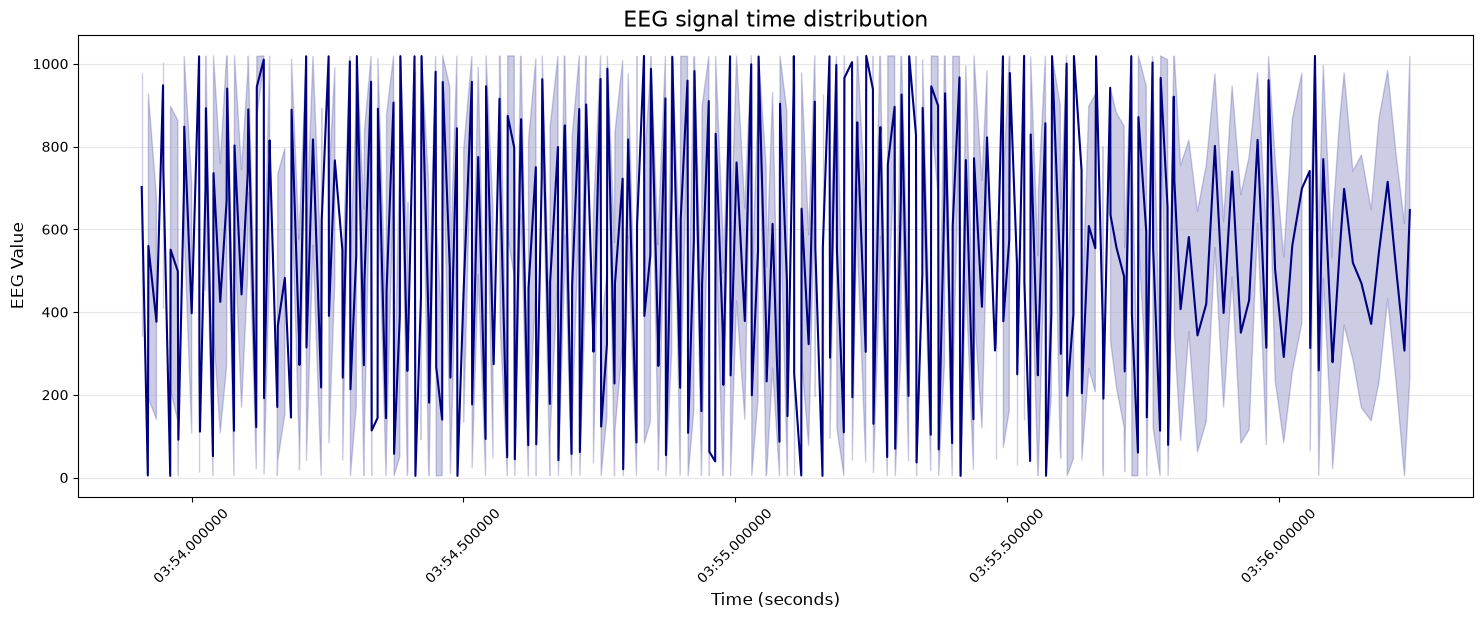

In [ ]:
plt.figure(figsize=(18,6))
sns.lineplot(data=df.head(1200), x='timestamp', y='value', color='navy', linewidth=1.5)
plt.title('Time Window-1', fontsize=16)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('EEG Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()